In [1]:
import os
import ast
import torch
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
from transformers import ClapModel, ClapProcessor
from pathlib import Path

# ── 1. CONFIGURACIÓN Y RUTAS ──
# Ajusta la ruta base según dónde esté tu notebook
PROJECT_ROOT = Path.cwd().parent # Ajusta si es necesario
DATASET_TSV = PROJECT_ROOT / 'mtg-jamendo-dataset' / 'data' / 'autotagging_moodtheme.tsv'
AUDIO_DIR = PROJECT_ROOT / 'data' / 'audio'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'embeddings_clap'

# Crear la carpeta para guardar los resultados si no existe
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cargar dataset completo
# ── Cargar dataset completo (Custom Parser para MTG-Jamendo) ──
print("Cargando dataset y procesando etiquetas variables...")

registros = []
with open(DATASET_TSV, 'r', encoding='utf-8') as f:
    cabecera = next(f) # Saltamos la primera línea (header)
    
    for linea in f:
        # Ignorar líneas vacías
        if not linea.strip(): continue
            
        columnas = linea.strip().split('\t')
        
        # Asegurarnos de que tiene al menos la información básica (hasta DURATION)
        if len(columnas) >= 6:
            # Limpiamos el track_id (ej: 'track_0003346' -> '3346')
            track_id = columnas[0].replace('track_', '').lstrip('0') 
            if track_id == '': track_id = '0'
                
            path = columnas[3]
            
            # Las etiquetas empiezan en el índice 5 hasta el final. 
            # Les quitamos el prefijo 'mood/theme---' para que encajen con tus 59 clases
            etiquetas = [tag.replace('mood/theme---', '') for tag in columnas[5:]]
            
            registros.append({
                'track_id': track_id,
                'path': path,
                'tags': etiquetas # Ya lo guardamos como lista directamente
            })

df_completo = pd.DataFrame(registros)

print(f"Total de canciones cargadas correctamente: {len(df_completo)}")

# ── 2. ETIQUETAS (LABEL LIST) ──
# ¡IMPORTANTE! Asegúrate de que esta sea tu lista oficial de 59 etiquetas.
# Aquí te pongo un ejemplo para extraerlas automáticamente del dataset si no las tienes a mano,
# pero si tienes tu lista 'label_list' ya definida, simplemente coméntalo y usa la tuya.
todas_las_etiquetas = set()
for tags in df_completo['tags']:
    todas_las_etiquetas.update(tags)
label_list = sorted(list(todas_las_etiquetas))
print(f"Número de etiquetas a clasificar: {len(label_list)}")

# ── 3. CARGAR MODELO CLAP ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

model_name = "laion/clap-htsat-unfused"
processor = ClapProcessor.from_pretrained(model_name)
model = ClapModel.from_pretrained(model_name).to(device)
model.eval()

# ── 4. PREPARAR TEXT EMBEDDINGS (El Prompt Campeón: 0.1732) ──
plantillas = [
    "A {} song."
]

print("Generando Vectores de Texto (Text Embeddings)...")
text_embeddings_list = []

with torch.no_grad():
    for label in label_list:
        textos = [p.format(label) for p in plantillas]
        inputs = processor(text=textos, return_tensors="pt", padding=True).to(device)
        text_features = model.get_text_features(**inputs)
        # Aunque sea 1 sola frase, hacemos mean para mantener la estructura tensorial
        text_features = text_features.mean(dim=0, keepdim=True) 
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        text_embeddings_list.append(text_features)

text_embeddings_matrix = torch.cat(text_embeddings_list, dim=0) # Shape: (59, 512)

# ── 5. BUCLE PRINCIPAL MASIVO (Zero-Shot + Extracción) ──
# ── 5. BUCLE PRINCIPAL MASIVO (CON SUBCARPETAS Y CHIVATO) ──
y_true_list = []
y_score_list = []
audio_embeddings_list = []
track_ids_validos = []

print("🚀 Iniciando extracción masiva sobre el dataset completo...")

archivos_no_encontrados = 0

for idx, row in tqdm(df_completo.iterrows(), total=len(df_completo)):
    track_id = str(row['track_id'])
    
    # Limpiamos los espacios invisibles que suelen dar problemas en Windows
    path_limpio = str(row['path']).strip() 
    
    # Construimos la ruta exacta uniendo el directorio de audio con "48/948.low.mp3"
    path_low = path_limpio.replace('.mp3', '.low.mp3')
    audio_path = AUDIO_DIR / path_low

    # Verificar si el archivo existe
    if not os.path.exists(audio_path):
        archivos_no_encontrados += 1
        # CHIVATO: Solo imprimimos el error de los 3 primeros para no saturar la pantalla
        if archivos_no_encontrados <= 3:
            print(f"\n[AVISO] No encuentro: {audio_path}")
        continue 
        
    try:
        # Cargar audio a 48kHz (requerido por CLAP)
        audio_array, _ = librosa.load(str(audio_path), sr=48000, duration=10.0) 
        
        # Procesar audio
        inputs = processor(audios=audio_array, return_tensors="pt", sampling_rate=48000).to(device)
        
        with torch.no_grad():
            # Extraer el EMBEDDING (Vector de 512 dimensiones)
            audio_features = model.get_audio_features(**inputs)
            
            audio_embeddings_list.append(audio_features.cpu().numpy().squeeze())
            track_ids_validos.append(track_id)
            
            # Calcular la predicción Zero-Shot
            audio_features = audio_features / audio_features.norm(dim=-1, keepdim=True)
            similarities = torch.matmul(audio_features, text_embeddings_matrix.T)
            probs = torch.sigmoid(similarities).cpu().numpy().squeeze()
            
        y_score_list.append(probs)
        
        real_tags = row['tags']
        y_true = np.zeros(len(label_list))
        for tag in real_tags:
            if tag in label_list:
                y_true[label_list.index(tag)] = 1
        y_true_list.append(y_true)
            
    except Exception as e:
        pass

# ... (La parte de GUARDAR RESULTADOS EN DISCO sigue igual)

# ── 6. GUARDAR RESULTADOS EN DISCO ──
print("\n💾 Guardando resultados (Embeddings y Predicciones)...")

# Guardar los embeddings y los IDs (Vital para la Fase 3)
np.save(OUTPUT_DIR / 'clap_audio_embeddings.npy', np.array(audio_embeddings_list))
np.save(OUTPUT_DIR / 'track_ids_embeddings.npy', np.array(track_ids_validos))

# Guardar las matrices de Zero-Shot para calcular métricas globales
np.save(OUTPUT_DIR / 'zero_shot_y_true_global.npy', np.array(y_true_list))
np.save(OUTPUT_DIR / 'zero_shot_y_score_global.npy', np.array(y_score_list))

print(f"✅ ¡Proceso completado con éxito! Se han analizado y extraído {len(track_ids_validos)} canciones.")
print(f"Archivos guardados en: {OUTPUT_DIR}")

c:\Users\Usuario\miniconda3\envs\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando dataset y procesando etiquetas variables...
Total de canciones cargadas correctamente: 18486
Número de etiquetas a clasificar: 59
Usando dispositivo: cuda
Generando Vectores de Texto (Text Embeddings)...
🚀 Iniciando extracción masiva sobre el dataset completo...


  0%|          | 0/18486 [00:00<?, ?it/s]C:\Users\Usuario\AppData\Local\Temp\ipykernel_22252\3565472640.py:130: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  inputs = processor(audios=audio_array, return_tensors="pt", sampling_rate=48000).to(device)
100%|██████████| 18486/18486 [16:12<00:00, 19.01it/s]



💾 Guardando resultados (Embeddings y Predicciones)...
✅ ¡Proceso completado con éxito! Se han analizado y extraído 18486 canciones.
Archivos guardados en: c:\Users\Usuario\OneDrive - UNIVERSIDAD DE MURCIA\Escritorio\CIENCIA DE DATOS RUBEN\CUARTO\TFG_Emociones\data\embeddings_clap


Cargando resultados de la Fase 2...
Reconstruyendo lista de etiquetas desde el TSV...
Matrices cargadas: y_true (18486, 59), y_score (18486, 59)
Etiquetas reconstruidas: 59
✅ Todo correcto. Procediendo al cálculo de métricas...

📊 CALCULANDO MÉTRICAS GLOBALES...
Metric               | Value     
-----------------------------------
mAP (Micro)          | 0.0490
mAP (Macro)          | 0.0542
ROC-AUC (Micro)      | 0.6270
ROC-AUC (Macro)      | 0.6268


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22252\3433652884.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ap.head(10), x='AP', y='Tag', palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_22252\3433652884.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ap.tail(10), x='AP', y='Tag', palette='magma')


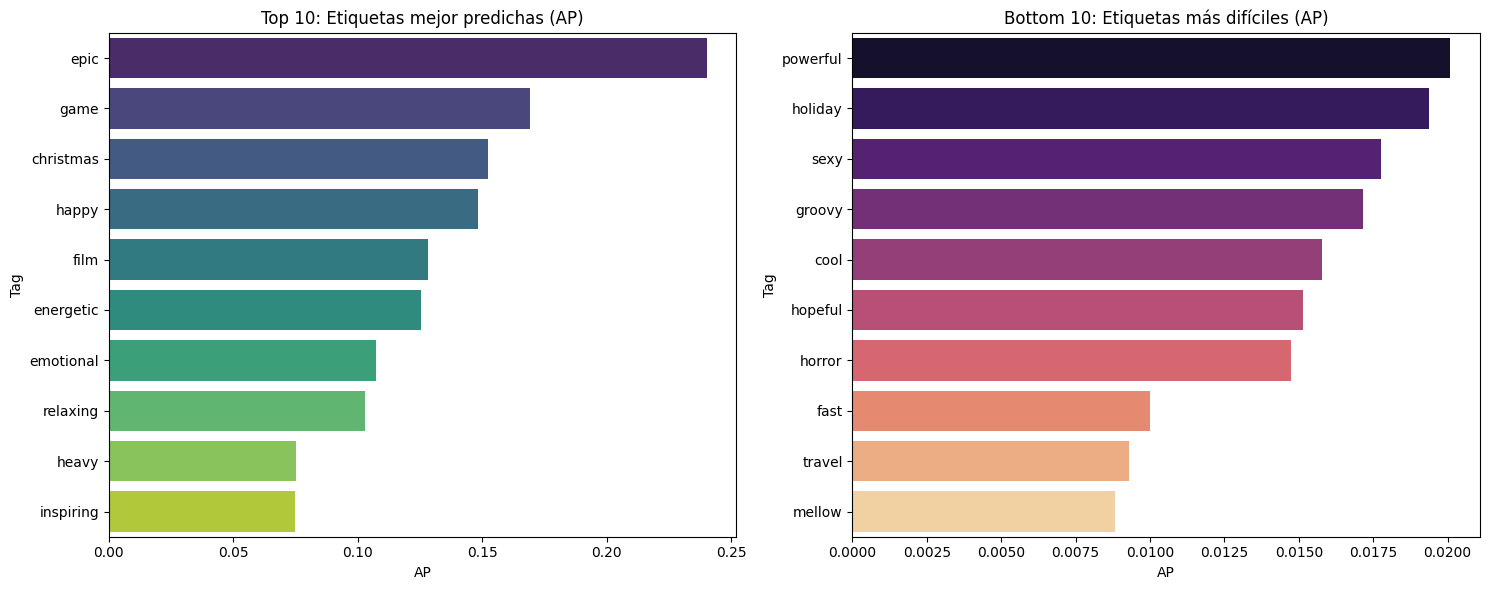

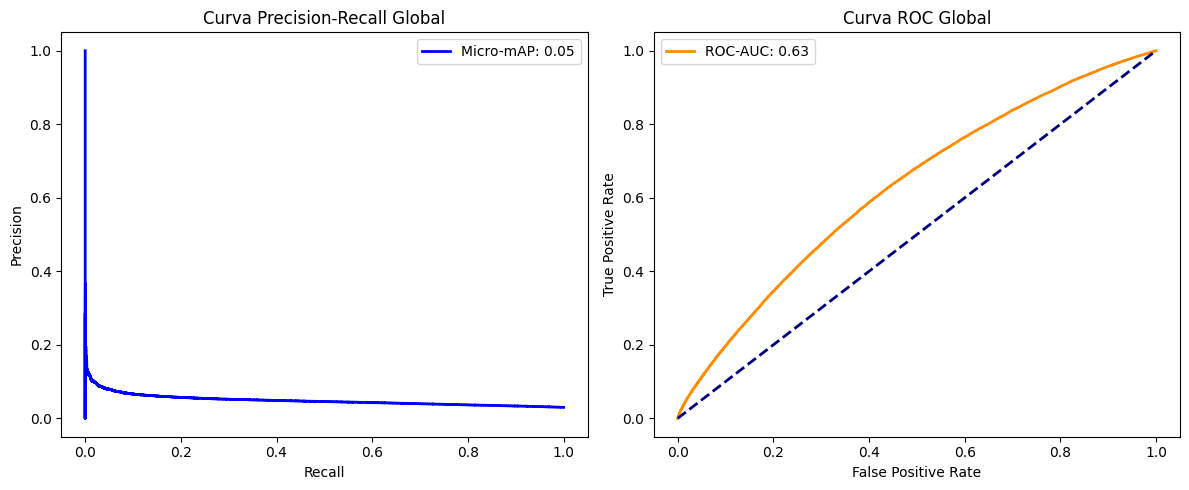


✅ Análisis completado. Gráficas guardadas en la carpeta de embeddings.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, roc_curve
from pathlib import Path

# ── 1. CARGAR DATOS ──
PROJECT_ROOT = Path.cwd().parent
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'embeddings_clap'
DATASET_TSV = PROJECT_ROOT / 'mtg-jamendo-dataset' / 'data' / 'autotagging_moodtheme.tsv'

print("Cargando resultados de la Fase 2...")
y_true = np.load(OUTPUT_DIR / 'zero_shot_y_true_global.npy')
y_score = np.load(OUTPUT_DIR / 'zero_shot_y_score_global.npy')

# Reconstruir label_list exactamente igual que en la extracción
print("Reconstruyendo lista de etiquetas desde el TSV...")
todas_las_etiquetas = set()

with open(DATASET_TSV, 'r', encoding='utf-8') as f:
    next(f) # Saltar cabecera
    for linea in f:
        if not linea.strip(): continue
        columnas = linea.strip().split('\t')
        if len(columnas) >= 6:
            # Quitamos el prefijo y extraemos todas las etiquetas de la fila
            tags = [tag.replace('mood/theme---', '') for tag in columnas[5:]]
            todas_las_etiquetas.update(tags)

# IMPORTANTE: Ordenar alfabéticamente para que coincida con las matrices .npy
label_list = sorted(list(todas_las_etiquetas))

print(f"Matrices cargadas: y_true {y_true.shape}, y_score {y_score.shape}")
print(f"Etiquetas reconstruidas: {len(label_list)}")

# Verificar que el número de etiquetas coincide con las columnas de las matrices
if len(label_list) != y_true.shape[1]:
    print("⚠️ ¡ERROR! El número de etiquetas no coincide con la matriz cargada.")
else:
    print("✅ Todo correcto. Procediendo al cálculo de métricas...")

# ── 2. CÁLCULO DE MÉTRICAS GLOBALES ──
print("\n📊 CALCULANDO MÉTRICAS GLOBALES...")
map_micro = average_precision_score(y_true, y_score, average='micro')
map_macro = average_precision_score(y_true, y_score, average='macro')
roc_auc_micro = roc_auc_score(y_true, y_score, average='micro')
roc_auc_macro = roc_auc_score(y_true, y_score, average='macro')

print(f"{'Metric':<20} | {'Value':<10}")
print("-" * 35)
print(f"{'mAP (Micro)':<20} | {map_micro:.4f}")
print(f"{'mAP (Macro)':<20} | {map_macro:.4f}")
print(f"{'ROC-AUC (Micro)':<20} | {roc_auc_micro:.4f}")
print(f"{'ROC-AUC (Macro)':<20} | {roc_auc_macro:.4f}")

# ── 3. ANÁLISIS POR ETIQUETA (Per-Class) ──
per_class_ap = []
for i in range(len(label_list)):
    ap = average_precision_score(y_true[:, i], y_score[:, i])
    per_class_ap.append({'Tag': label_list[i], 'AP': ap})

df_ap = pd.DataFrame(per_class_ap).sort_values(by='AP', ascending=False)

# ── 4. VISUALIZACIONES ──

# FIGURA 1: Top 10 y Bottom 10 Etiquetas
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_ap.head(10), x='AP', y='Tag', palette='viridis')
plt.title('Top 10: Etiquetas mejor predichas (AP)')

plt.subplot(1, 2, 2)
sns.barplot(data=df_ap.tail(10), x='AP', y='Tag', palette='magma')
plt.title('Bottom 10: Etiquetas más difíciles (AP)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_bottom_tags.png')
plt.show()

# FIGURA 2: Curvas PR y ROC (Micro-average)
precision, recall, _ = precision_recall_curve(y_true.ravel(), y_score.ravel())
fpr, tpr, _ = roc_curve(y_true.ravel(), y_score.ravel())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall, precision, color='blue', lw=2, label=f'Micro-mAP: {map_micro:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall Global')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-AUC: {roc_auc_micro:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Global')
plt.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'global_curves.png')
plt.show()

print("\n✅ Análisis completado. Gráficas guardadas en la carpeta de embeddings.")